In [1]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(".").resolve()
RAW = ROOT / "data" / "raw"

EVENTS_PATH = RAW / "events.csv"
PROPS1_PATH = RAW / "item_properties_part1.csv"
PROPS2_PATH = RAW / "item_properties_part2.csv"
CATEGORY_TREE_PATH = RAW / "category_tree.csv"

CHUNKSIZE = 1_000_000

In [2]:
def scan_csv(paths, *, usecols, top_col=None, ts_col=None, ts_unit=None, chunksize=CHUNKSIZE):
    if isinstance(paths, (str, Path)):
        paths = [paths]

    rows = 0
    missing = Counter()
    top = Counter()
    ts_min = None
    ts_max = None
    head = None

    for p in map(Path, paths):
        for chunk in pd.read_csv(p, usecols=usecols, chunksize=chunksize):
            if head is None:
                head = chunk.head(5)

            rows += len(chunk)
            missing.update(chunk.isna().sum().to_dict())

            if top_col:
                top.update(chunk[top_col].dropna().astype(str))

            if ts_col:
                s = chunk[ts_col].dropna()
                if not s.empty:
                    ts_min = s.min() if ts_min is None else min(ts_min, s.min())
                    ts_max = s.max() if ts_max is None else max(ts_max, s.max())

    if ts_col and ts_unit and ts_min is not None:
        ts_min = pd.to_datetime(ts_min, unit=ts_unit, utc=True)
        ts_max = pd.to_datetime(ts_max, unit=ts_unit, utc=True)

    return {"rows": rows, "missing": missing, "top": top, "ts_min": ts_min, "ts_max": ts_max, "head": head}

In [3]:
def show_scan(name, s, *, top_k=None, missing_min_pct=0.0):
    print(f"\n--- {name} ---")
    display(s["head"])
    print(f"rows: {s['rows']:,}")

    if s["ts_min"] is not None:
        print(f"time min utc: {s['ts_min']}")
        print(f"time max utc: {s['ts_max']}")

    missing_items = [
        (col, cnt, (cnt / s["rows"]) * 100)
        for col, cnt in s["missing"].items()
        if cnt > 0
    ]
    missing_items.sort(key=lambda x: x[2], reverse=True)
    missing_items = [x for x in missing_items if x[2] >= missing_min_pct]

    if missing_items:
        print(f"missing (>= {missing_min_pct}%):")
        for col, cnt, pct in missing_items:
            print(f"- {col}: {cnt:,} ({pct:.2f}%)")
    else:
        print("missing: none")

    if top_k is not None and s["top"]:
        print(f"top {top_k}:")
        for k, v in s["top"].most_common(top_k):
            print(f"- {k}: {v:,}")

In [4]:
category_scan = scan_csv(
    CATEGORY_TREE_PATH,
    usecols=["categoryid", "parentid"],
)

events_scan = scan_csv(
    EVENTS_PATH,
    usecols=["timestamp", "visitorid", "event", "itemid", "transactionid"],
    ts_col="timestamp",
    ts_unit="ms",
    top_col="event",
)

props_scan = scan_csv(
    [PROPS1_PATH, PROPS2_PATH],
    usecols=["timestamp", "itemid", "property", "value"],
    ts_col="timestamp",
    ts_unit="ms",
    top_col="property",
)

In [5]:
show_scan("category_tree", category_scan, top_k=None, missing_min_pct=0.1)
show_scan("events", events_scan, top_k=3, missing_min_pct=0.1)
show_scan("item_properties", props_scan, top_k=10, missing_min_pct=0.1)


--- category_tree ---


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


rows: 1,669
missing (>= 0.1%):
- parentid: 25 (1.50%)

--- events ---


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


rows: 2,756,101
time min utc: 2015-05-03 03:00:04.384000+00:00
time max utc: 2015-09-18 02:59:47.788000+00:00
missing (>= 0.1%):
- transactionid: 2,733,644 (99.19%)
top 3:
- view: 2,664,312
- addtocart: 69,332
- transaction: 22,457

--- item_properties ---


,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


rows: 20,275,902
time min utc: 2015-05-10 03:00:00+00:00
time max utc: 2015-09-13 03:00:00+00:00
missing: none
top 10:
- 888: 3,000,398
- 790: 1,790,516
- available: 1,503,639
- categoryid: 788,214
- 6: 631,471
- 283: 597,419
- 776: 574,220
- 678: 481,966
- 364: 476,486
- 202: 448,938


In [6]:
user_counts = scan_csv(EVENTS_PATH, usecols=["visitorid"], top_col="visitorid")["top"]
item_counts = scan_csv(EVENTS_PATH, usecols=["itemid"], top_col="itemid")["top"]

num_users = len(user_counts)
num_items = len(item_counts)
num_interactions = events_scan["rows"]

sparsity = 1 - (num_interactions / (num_users * num_items))

user_freq = np.fromiter(user_counts.values(), dtype=np.int64)
item_freq = np.fromiter(item_counts.values(), dtype=np.int64)

print(f"users: {num_users:,}")
print(f"items: {num_items:,}")
print(f"interactions: {num_interactions:,}")
print(f"sparsity: {sparsity:.6%}")

print("\nevents per user:", f"median={np.median(user_freq):.0f}", f"p90={np.percentile(user_freq, 90):.0f}", f"p99={np.percentile(user_freq, 99):.0f}")
print("events per item:", f"median={np.median(item_freq):.0f}", f"p90={np.percentile(item_freq, 90):.0f}", f"p99={np.percentile(item_freq, 99):.0f}")

users: 1,407,580
items: 235,061
interactions: 2,756,101
sparsity: 99.999167%

events per user: median=1 p90=3 p99=13
events per item: median=3 p90=25 p99=143


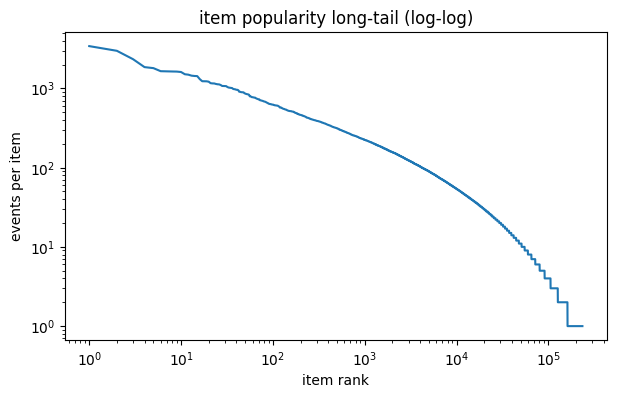

In [7]:
item_sorted = np.sort(item_freq)[::-1]
ranks = np.arange(1, item_sorted.size + 1)

plt.figure(figsize=(7, 4))
plt.loglog(ranks, item_sorted)
plt.xlabel("item rank")
plt.ylabel("events per item")
plt.title("item popularity long-tail (log-log)")
plt.show()

In [10]:
event_counts = events_scan["top"]

views = event_counts.get("view", 0)
carts = event_counts.get("addtocart", 0)
purchases = event_counts.get("transaction", 0)

print(f"view -> cart: {carts / views:.6f}")
print(f"cart -> purchase: {purchases / carts:.6f}")
print(f"view -> purchase: {purchases / views:.6f}")

view -> cart: 0.026022
cart -> purchase: 0.323905
view -> purchase: 0.008429


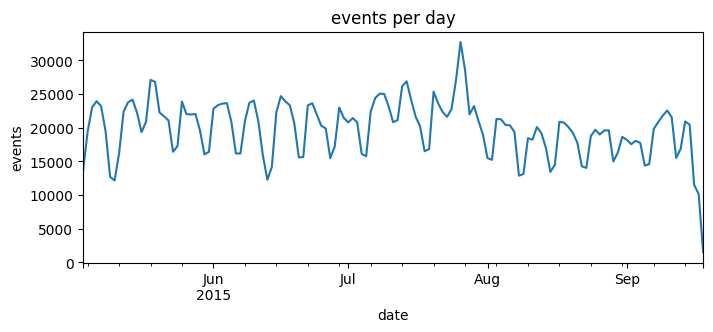

In [9]:
daily = Counter()
for chunk in pd.read_csv(EVENTS_PATH, usecols=["timestamp"], chunksize=CHUNKSIZE):
    days = pd.to_datetime(chunk["timestamp"], unit="ms", utc=True).dt.floor("D")
    daily.update(days.tolist())

daily_series = pd.Series(daily).sort_index()
daily_series.index = pd.to_datetime(daily_series.index)

daily_series.plot(figsize=(8, 3), title="events per day")
plt.xlabel("date")
plt.ylabel("events")
plt.show()

EDA Summary
Dataset: ~2.76M events, 1.41M users, 235K items (May–Sep 2015, ~4.5 months)
Item properties: 20.3M rows | Category tree: 1,669 nodes (25 roots)

Key findings:
- sparsity 99.999%: median 1 event/user, 3 events/item -> cold-start dominant
- item popularity follows power-law (long-tail)
- funnel: view -> cart 2.6%, cart -> buy 32.4%, view -> buy 0.84%
- transactionid missing 99.2% (expected: most events are views)
- item properties need parsing

Implications for modeling:
- pure collaborative filtering is impractical at this sparsity
- leverage content features (category, item properties) or session-based models
- apply core-filtering (min interaction threshold) to reduce noise
- biggest conversion gap is view -> cart — main target for recommendations